In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

In [8]:
df = pd.read_csv("../data/laptop_price.csv", encoding="latin1")
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [9]:
df.dtypes

laptop_ID             int64
Company                 str
Product                 str
TypeName                str
Inches              float64
ScreenResolution        str
Cpu                     str
Ram                     str
Memory                  str
Gpu                     str
OpSys                   str
Weight                  str
Price_euros         float64
dtype: object

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   str    
 2   Product           1303 non-null   str    
 3   TypeName          1303 non-null   str    
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   str    
 6   Cpu               1303 non-null   str    
 7   Ram               1303 non-null   str    
 8   Memory            1303 non-null   str    
 9   Gpu               1303 non-null   str    
 10  OpSys             1303 non-null   str    
 11  Weight            1303 non-null   str    
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), str(10)
memory usage: 132.5 KB


In [11]:
# Dataset shape
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1303
Columns: 13


In [12]:
# Summary statistics
df.describe(include="all")

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
count,1303.000000,1303,1303,1303,1303.000000,1303,1303,1303,1303,1303,1303,1303,1303.000000
unique,NaN,19,618,6,NaN,40,118,9,39,110,9,179,NaN
top,NaN,Dell,XPS 13,Notebook,NaN,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.2kg,NaN
freq,NaN,297,30,727,NaN,507,190,619,412,281,1072,121,NaN
mean,660.155794,NaN,NaN,NaN,15.017191,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1123.686992
std,381.172104,NaN,NaN,NaN,1.426304,NaN,NaN,NaN,NaN,NaN,NaN,NaN,699.009043
min,1.000000,NaN,NaN,NaN,10.100000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,174.000000
25%,331.500000,NaN,NaN,NaN,14.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,599.000000
50%,659.000000,NaN,NaN,NaN,15.600000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,977.000000
75%,990.500000,NaN,NaN,NaN,15.600000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1487.880000


In [13]:
# Column names
df.columns

Index(['laptop_ID', 'Company', 'Product', 'TypeName', 'Inches',
       'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight',
       'Price_euros'],
      dtype='str')

In [14]:
# Check missing values
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [15]:
# Check duplicate rows

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [16]:
# Preview unique values in each column

for col in df.columns:
    print(df[col].nunique())
    print(df[col].unique()[:10])

1303
[ 1  2  3  4  5  6  7  8  9 10]
19
<StringArray>
[    'Apple',        'HP',      'Acer',      'Asus',      'Dell',    'Lenovo',
     'Chuwi',       'MSI', 'Microsoft',   'Toshiba']
Length: 10, dtype: str
618
<StringArray>
[      'MacBook Pro',       'Macbook Air',            '250 G6',
          'Aspire 3',   'ZenBook UX430UN',           'Swift 3',
     'Inspiron 3567',       'MacBook 12"', 'IdeaPad 320-15IKB',
            'XPS 13']
Length: 10, dtype: str
6
<StringArray>
[         'Ultrabook',           'Notebook',            'Netbook',
             'Gaming', '2 in 1 Convertible',        'Workstation']
Length: 6, dtype: str
18
[13.3 15.6 15.4 14.  12.  11.6 17.3 10.1 13.5 12.5]
40
<StringArray>
[       'IPS Panel Retina Display 2560x1600',
                                  '1440x900',
                         'Full HD 1920x1080',
        'IPS Panel Retina Display 2880x1800',
                                  '1366x768',
               'IPS Panel Full HD 1920x1080',
        'IPS Pan

In [17]:
# Make a copy for EDA
eda_df = df.copy()

In [18]:
# Clean RAM column
eda_df["Ram"] = eda_df["Ram"].str.replace("GB", "", regex=False).astype(int)

In [19]:
# Clean Weight column
eda_df["Weight"] = eda_df["Weight"].str.replace("kg", "", regex=False).astype(float)

In [20]:
# Rename price column if needed
eda_df.rename(columns={"Price_euros": "Price"}, inplace=True)
eda_df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,1803.60


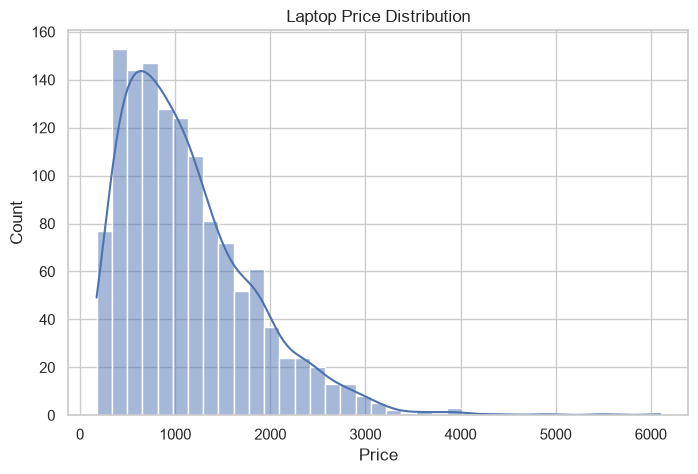

In [21]:
# Price Distribution

plt.figure(figsize=(8, 5))
sns.histplot(eda_df["Price"], kde=True)
plt.title("Laptop Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

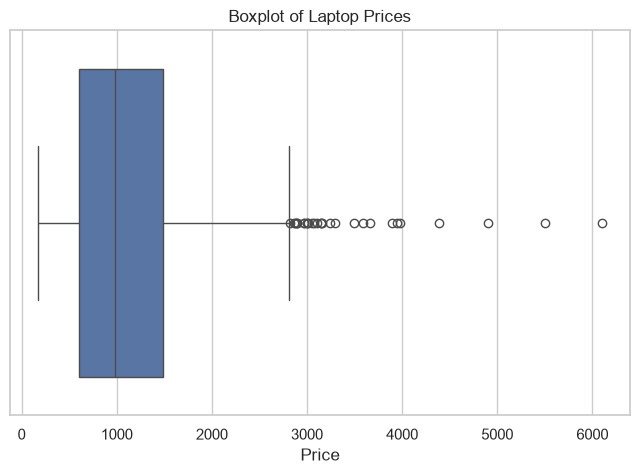

In [22]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=eda_df["Price"])
plt.title("Boxplot of Laptop Prices")
plt.xlabel("Price")
plt.show()

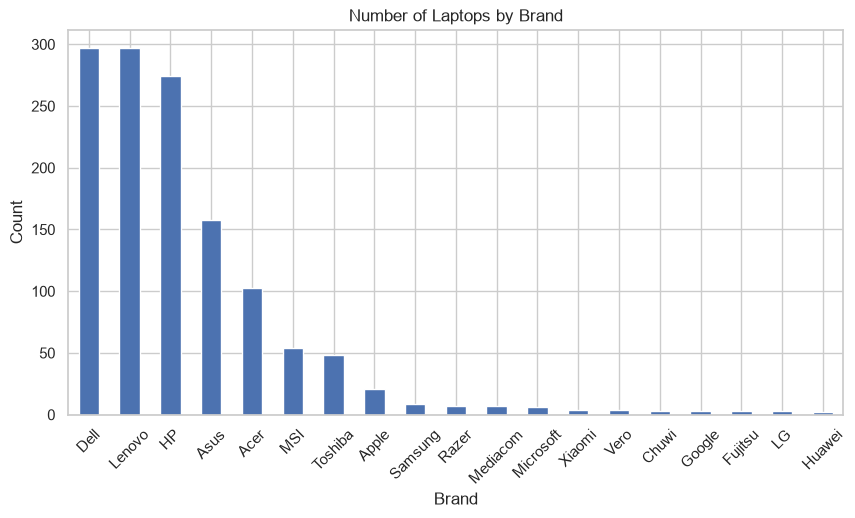

In [23]:
# Brand Analysis

plt.figure(figsize=(10, 5))
eda_df["Company"].value_counts().plot(kind="bar")
plt.title("Number of Laptops by Brand")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

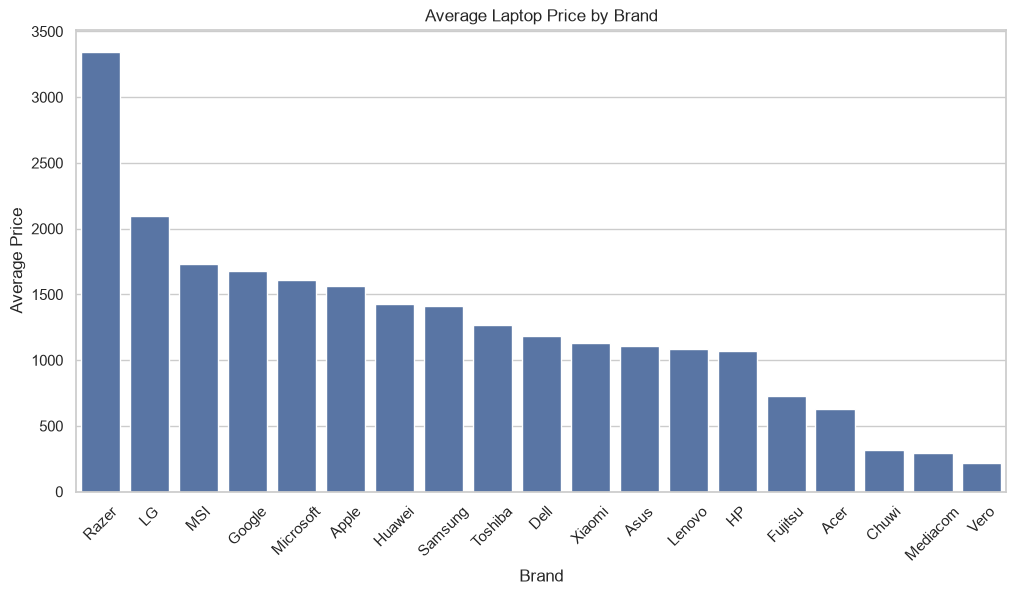

In [24]:
plt.figure(figsize=(12, 6))
brand_price = eda_df.groupby("Company")["Price"].mean().sort_values(ascending=False)

sns.barplot(x=brand_price.index, y=brand_price.values)
plt.title("Average Laptop Price by Brand")
plt.xlabel("Brand")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

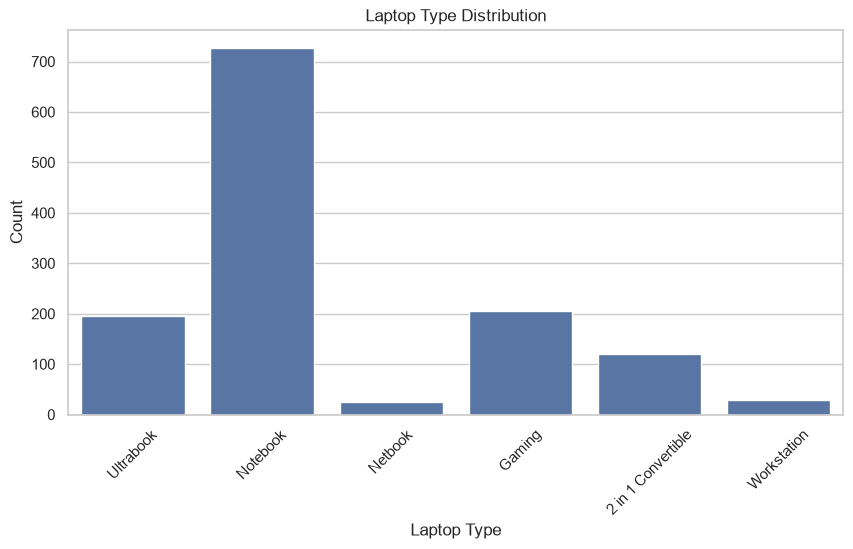

In [25]:
# Laptop Type Analysis

plt.figure(figsize=(10, 5))
sns.countplot(x="TypeName", data=eda_df)
plt.title("Laptop Type Distribution")
plt.xlabel("Laptop Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

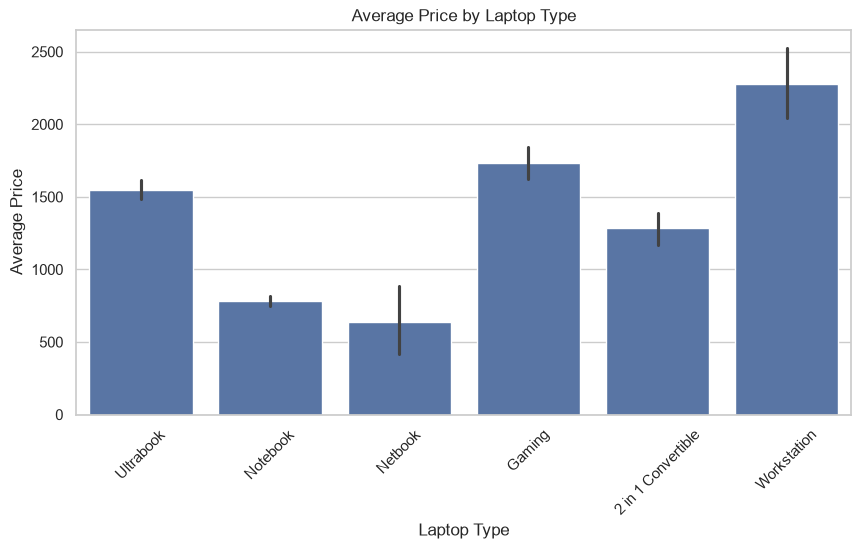

In [26]:
plt.figure(figsize=(10, 5))
sns.barplot(x="TypeName", y="Price", data=eda_df)
plt.title("Average Price by Laptop Type")
plt.xlabel("Laptop Type")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

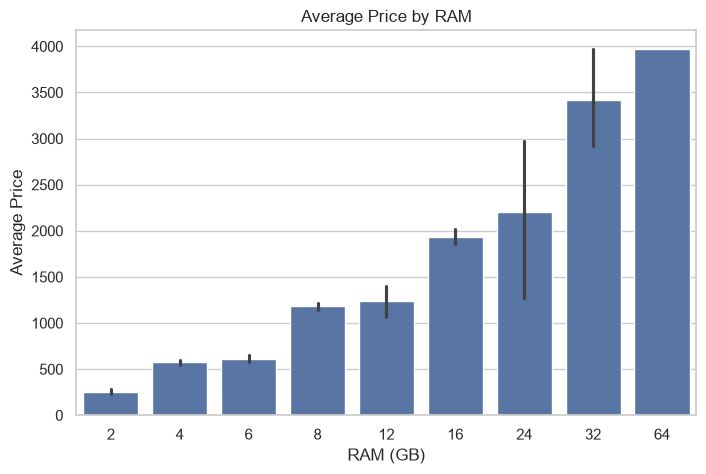

In [27]:
# RAM vs Price

plt.figure(figsize=(8, 5))
sns.barplot(x="Ram", y="Price", data=eda_df)
plt.title("Average Price by RAM")
plt.xlabel("RAM (GB)")
plt.ylabel("Average Price")
plt.show()

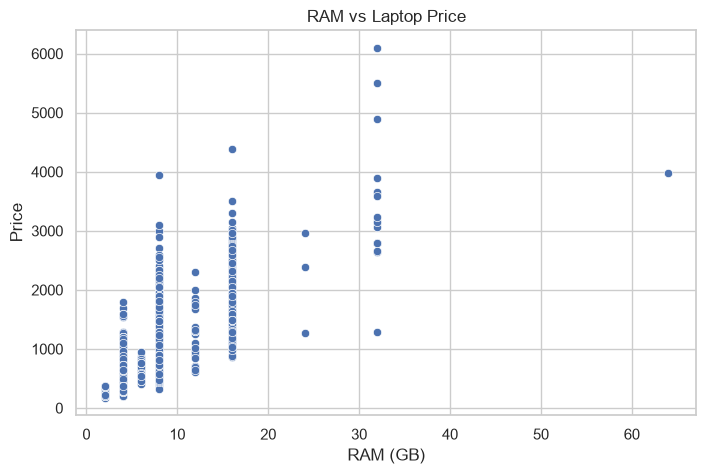

In [28]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Ram", y="Price", data=eda_df)
plt.title("RAM vs Laptop Price")
plt.xlabel("RAM (GB)")
plt.ylabel("Price")
plt.show()

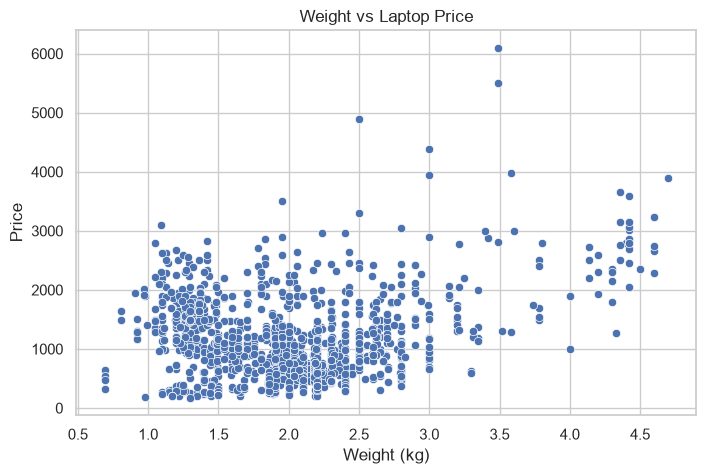

In [29]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Weight", y="Price", data=eda_df)
plt.title("Weight vs Laptop Price")
plt.xlabel("Weight (kg)")
plt.ylabel("Price")
plt.show()

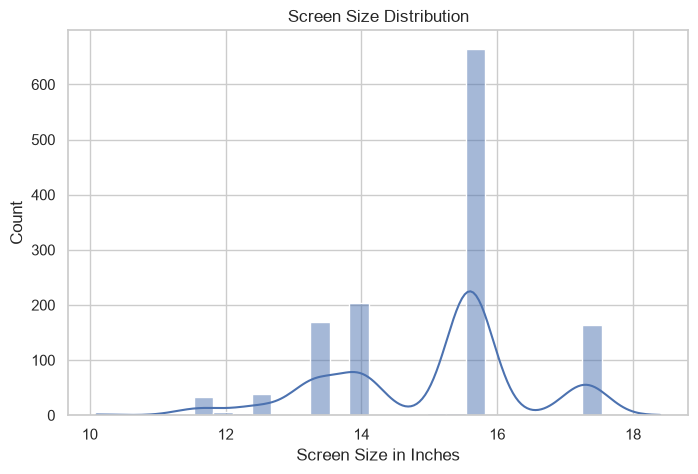

In [30]:
plt.figure(figsize=(8, 5))
sns.histplot(eda_df["Inches"], kde=True)
plt.title("Screen Size Distribution")
plt.xlabel("Screen Size in Inches")
plt.ylabel("Count")
plt.show()

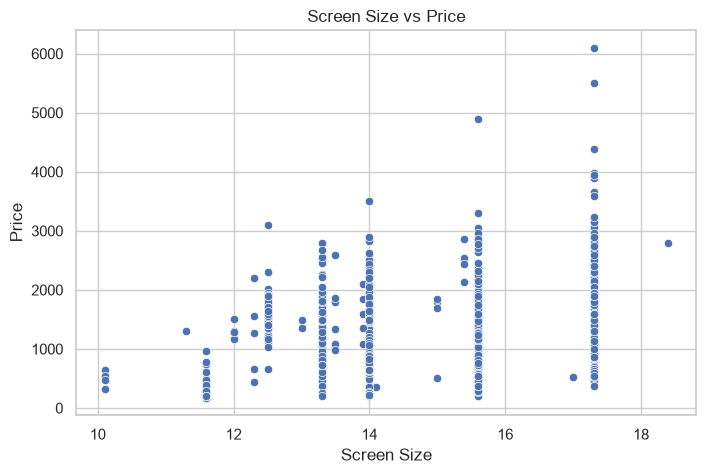

In [31]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Inches", y="Price", data=eda_df)
plt.title("Screen Size vs Price")
plt.xlabel("Screen Size")
plt.ylabel("Price")
plt.show()

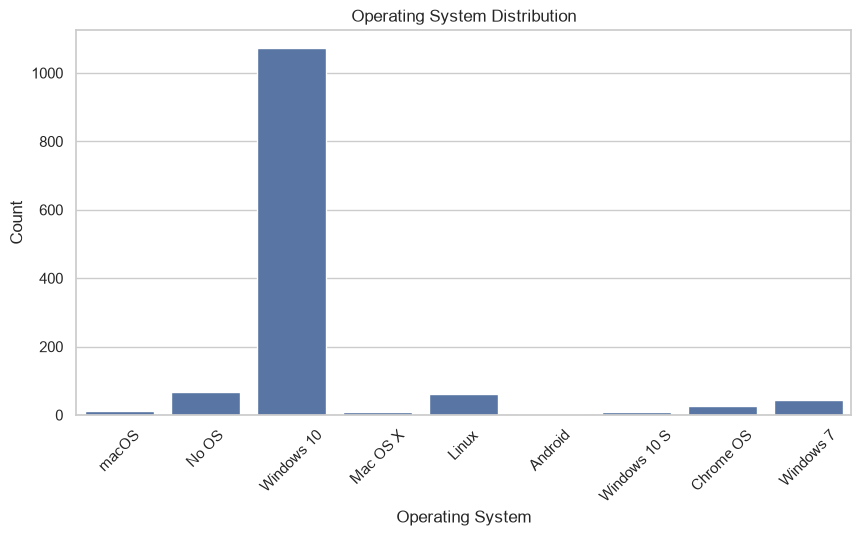

In [32]:
plt.figure(figsize=(10, 5))
sns.countplot(x="OpSys", data=eda_df)
plt.title("Operating System Distribution")
plt.xlabel("Operating System")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

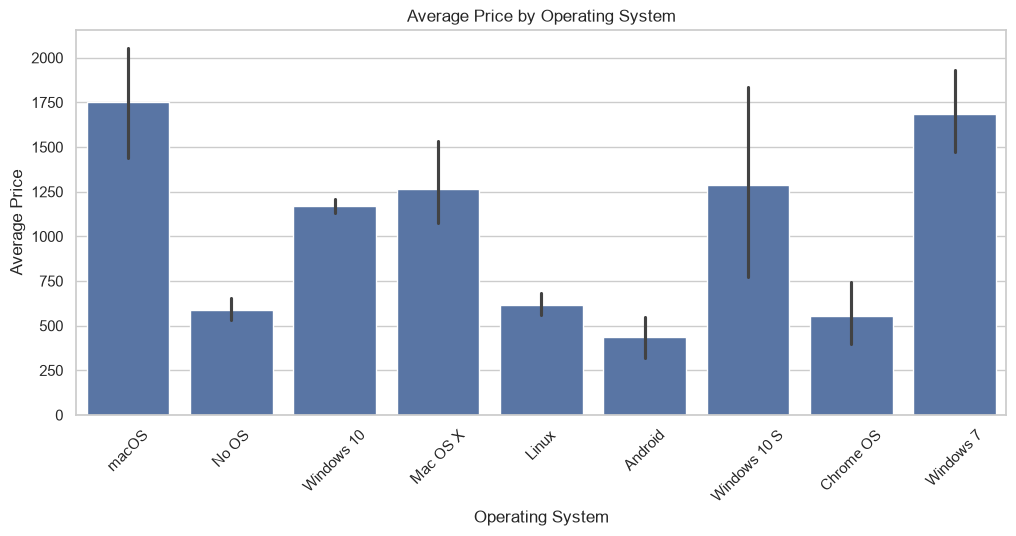

In [33]:
plt.figure(figsize=(12, 5))
sns.barplot(x="OpSys", y="Price", data=eda_df)
plt.title("Average Price by Operating System")
plt.xlabel("Operating System")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

In [34]:
eda_df["Cpu"].value_counts().head(10)

Cpu
Intel Core i5 7200U 2.5GHz     190
Intel Core i7 7700HQ 2.8GHz    146
Intel Core i7 7500U 2.7GHz     134
Intel Core i7 8550U 1.8GHz      73
Intel Core i5 8250U 1.6GHz      72
Intel Core i5 6200U 2.3GHz      68
Intel Core i3 6006U 2GHz        64
Intel Core i7 6500U 2.5GHz      49
Intel Core i7 6700HQ 2.6GHz     43
Intel Core i3 7100U 2.4GHz      37
Name: count, dtype: int64

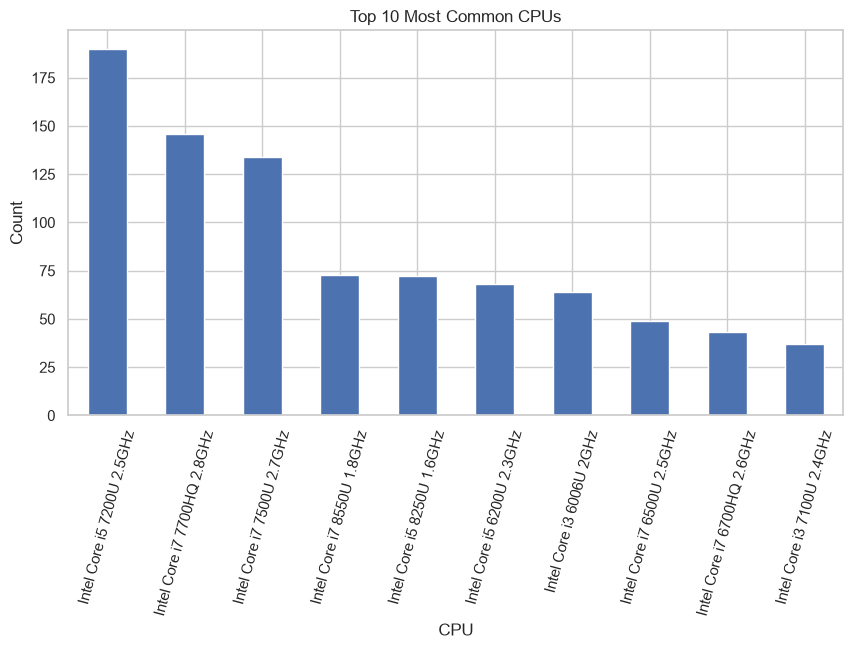

In [35]:
plt.figure(figsize=(10, 5))
eda_df["Cpu"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Most Common CPUs")
plt.xlabel("CPU")
plt.ylabel("Count")
plt.xticks(rotation=75)
plt.show()

In [36]:
eda_df["Gpu"].value_counts().head(10)

Gpu
Intel HD Graphics 620      281
Intel HD Graphics 520      185
Intel UHD Graphics 620      68
Nvidia GeForce GTX 1050     66
Nvidia GeForce GTX 1060     48
Nvidia GeForce 940MX        43
AMD Radeon 530              41
Intel HD Graphics 500       39
Intel HD Graphics 400       37
Nvidia GeForce GTX 1070     30
Name: count, dtype: int64

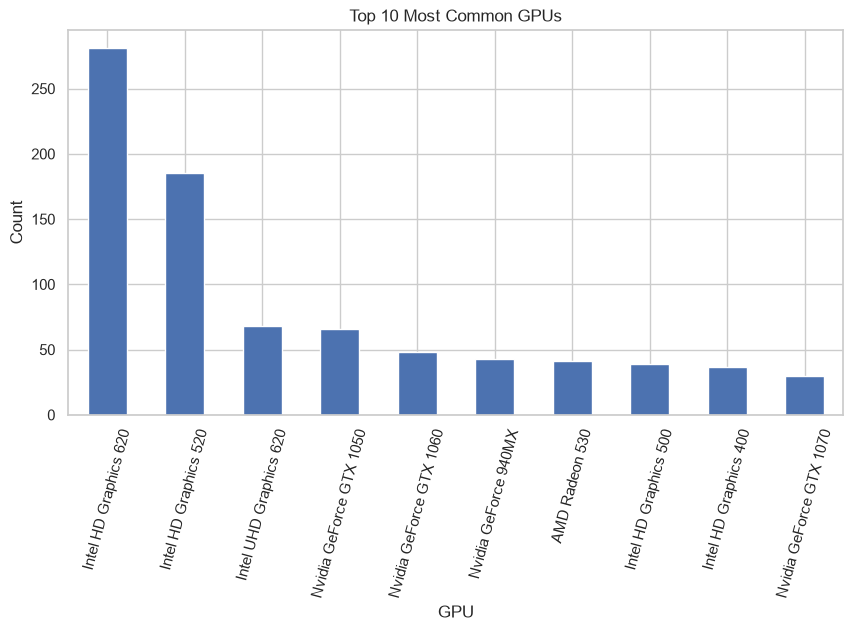

In [37]:
plt.figure(figsize=(10, 5))
eda_df["Gpu"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Most Common GPUs")
plt.xlabel("GPU")
plt.ylabel("Count")
plt.xticks(rotation=75)
plt.show()

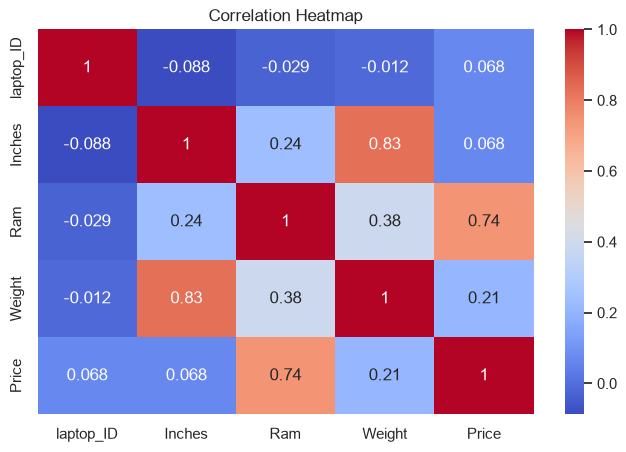

In [38]:
numeric_cols = eda_df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(8, 5))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

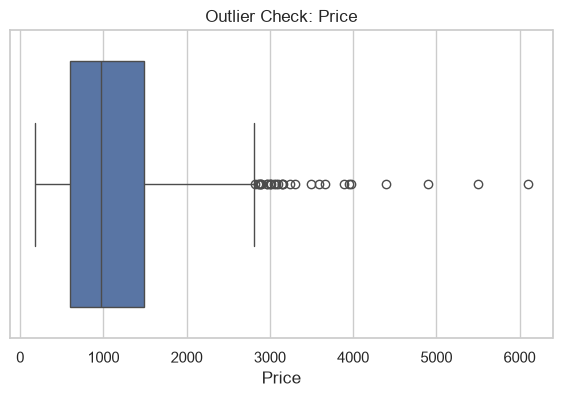

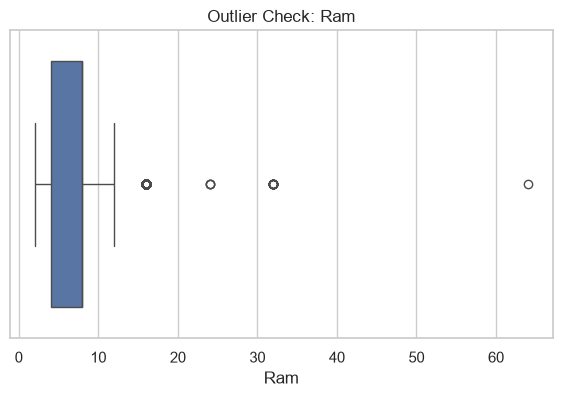

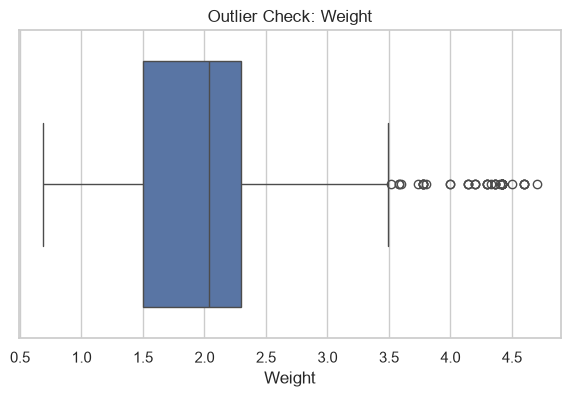

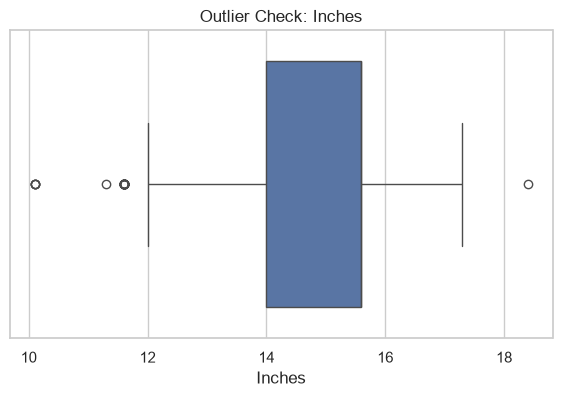

In [39]:
numeric_columns = ["Price", "Ram", "Weight", "Inches"]
for col in numeric_columns:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=eda_df[col])
    plt.title(f"Outlier Check: {col}")
    plt.show()